In [9]:
# Core libraries
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Modelling
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, auc)
import xgboost as xgb
import joblib
import os
os.makedirs('outputs', exist_ok=True)

# Plot settings
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
pio.templates.default = "plotly_white"
pio.kaleido.scope.default_scale = 2  # crisper static plotly exports

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [10]:
red_df = pd.read_csv('data/winequality-red.csv', sep=';')
white_df = pd.read_csv('data/winequality-white.csv', sep=';')

red_df['wine_type'] = 'red'
white_df['wine_type'] = 'white'

print(f"Red wine samples:   {red_df.shape[0]:>5}  |  Columns: {red_df.shape[1]}")
print(f"White wine samples: {white_df.shape[0]:>5}  |  Columns: {white_df.shape[1]}")

df = pd.concat([red_df, white_df], ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")
df.head()


Red wine samples:    1599  |  Columns: 13
White wine samples:  4898  |  Columns: 13

Combined dataset shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 689.4 KB


In [12]:
df.describe().T.style.background_gradient(cmap='Blues')


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.000000,7.215307,1.296434,3.800000,6.400000,7.000000,7.700000,15.900000
volatile acidity,6497.000000,0.339666,0.164636,0.080000,0.230000,0.290000,0.400000,1.580000
citric acid,6497.000000,0.318633,0.145318,0.000000,0.250000,0.310000,0.390000,1.660000
residual sugar,6497.000000,5.443235,4.757804,0.600000,1.800000,3.000000,8.100000,65.800000
chlorides,6497.000000,0.056034,0.035034,0.009000,0.038000,0.047000,0.065000,0.611000
free sulfur dioxide,6497.000000,30.525319,17.749400,1.000000,17.000000,29.000000,41.000000,289.000000
total sulfur dioxide,6497.000000,115.744574,56.521855,6.000000,77.000000,118.000000,156.000000,440.000000
density,6497.000000,0.994697,0.002999,0.987110,0.992340,0.994890,0.996990,1.038980
pH,6497.000000,3.218501,0.160787,2.720000,3.110000,3.210000,3.320000,4.010000
sulphates,6497.000000,0.531268,0.148806,0.220000,0.430000,0.510000,0.600000,2.000000


In [13]:
print("Missing values per column:")
print(df.isnull().sum())

n_dupes = df.duplicated().sum()
print(f"\nExact duplicate rows: {n_dupes} ({n_dupes/len(df):.1%} of the data)")


Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

Exact duplicate rows: 1177 (18.1% of the data)


In [14]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Rows before dedup: {before}  ->  Rows after dedup: {after}  (removed {before - after})")


Rows before dedup: 6497  ->  Rows after dedup: 5320  (removed 1177)


In [15]:
# Sanity-check value ranges make physical sense (no negatives, extreme outliers, etc.)
df.describe().T[['min', 'max']]


,min,max
fixed acidity,3.80000,15.90000
volatile acidity,0.08000,1.58000
citric acid,0.00000,1.66000
residual sugar,0.60000,65.80000
chlorides,0.00900,0.61100
free sulfur dioxide,1.00000,289.00000
total sulfur dioxide,6.00000,440.00000
density,0.98711,1.03898
pH,2.72000,4.01000
sulphates,0.22000,2.00000


### 4.1 Quality score distribution

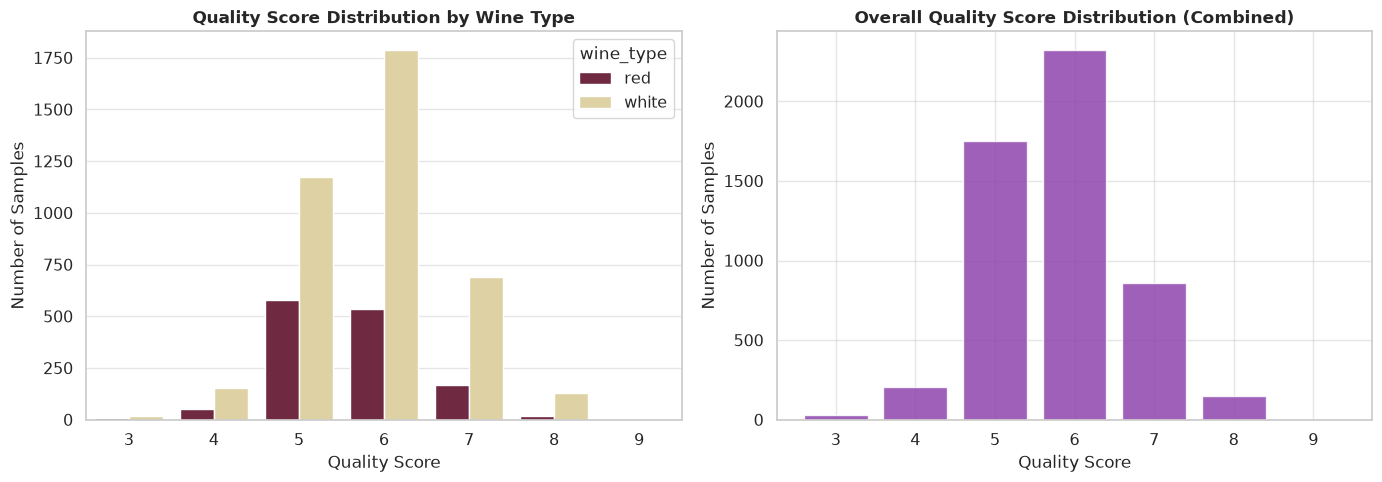

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='quality', hue='wine_type',
              palette={'red': '#7b1e3d', 'white': '#e8d79a'}, ax=axes[0])
axes[0].set_title('Quality Score Distribution by Wine Type')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Number of Samples')

quality_counts = df['quality'].value_counts().sort_index()
axes[1].bar(quality_counts.index, quality_counts.values, color='#8e44ad', alpha=0.85)
axes[1].set_title('Overall Quality Score Distribution (Combined)')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.savefig('outputs/01_quality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
print("The dataset is naturally imbalanced: most wines score 5-6 ('average'),")
print("with far fewer samples at the extremes (3, 4, 8, 9). This has direct implications")
print("for modelling choices made later in the notebook (see Section 5).")
df.groupby('wine_type')['quality'].describe()


The dataset is naturally imbalanced: most wines score 5-6 ('average'),
with far fewer samples at the extremes (3, 4, 8, 9). This has direct implications
for modelling choices made later in the notebook (see Section 5).


,count,mean,std,min,25%,50%,75%,max
wine_type,,,,,,,,
red,1359.0,5.623252,0.823578,3.0,5.0,6.0,6.0,8.0
white,3961.0,5.854835,0.890683,3.0,5.0,6.0,6.0,9.0


### 4.2 Feature distributions (red vs. white)

In [19]:
print("Red and white wines are clearly separable on several chemistry axes -- most notably")
print("total/free sulfur dioxide (white wines are typically sulphured more heavily as a")
print("preservative), residual sugar, and volatile acidity. This justifies keeping wine_type")
print("as an explicit model feature rather than modelling the two wine types as identical.")


Red and white wines are clearly separable on several chemistry axes -- most notably
total/free sulfur dioxide (white wines are typically sulphured more heavily as a
preservative), residual sugar, and volatile acidity. This justifies keeping wine_type
as an explicit model feature rather than modelling the two wine types as identical.


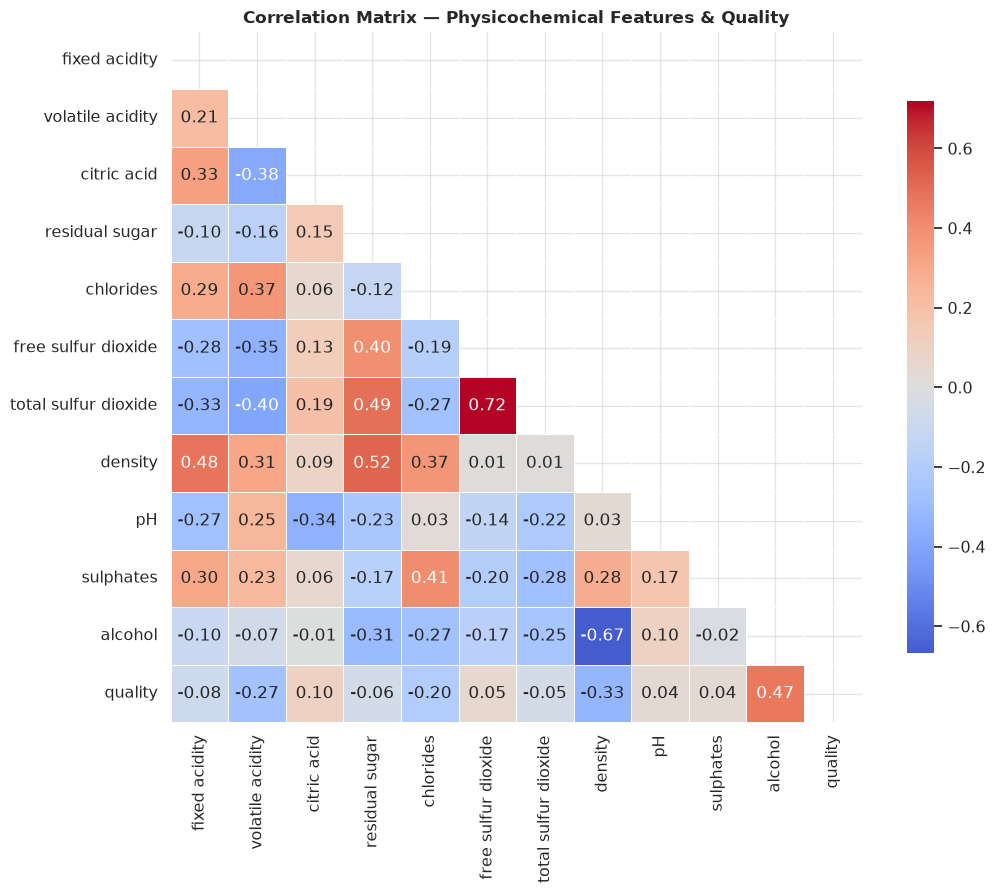

In [20]:
numeric_df = df.drop(columns=['wine_type'])
corr = numeric_df.corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Physicochemical Features & Quality')
plt.tight_layout()
plt.savefig('outputs/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
quality_corr = corr['quality'].drop('quality').sort_values(key=abs, ascending=False)
print("Features most correlated with quality (by absolute Pearson correlation):")
quality_corr


Features most correlated with quality (by absolute Pearson correlation):


alcohol                 0.469422
density                -0.326434
volatile acidity       -0.265205
chlorides              -0.202137
citric acid             0.097954
fixed acidity          -0.080092
residual sugar         -0.056830
free sulfur dioxide     0.054002
total sulfur dioxide   -0.050296
sulphates               0.041884
pH                      0.039733
Name: quality, dtype: float64

### 4.4 Interactive Plotly visualizations

Interactive charts make it easier to explore relationships between multiple variables at once
(hover for exact values, zoom into regions of interest).

In [22]:
fig = px.box(df, x='quality', y='alcohol', color='wine_type',
             color_discrete_map={'red': '#7b1e3d', 'white': '#c9a94f'},
             title='Alcohol Content by Quality Score and Wine Type',
             labels={'alcohol': 'Alcohol (% vol)', 'quality': 'Quality Score'})
fig.update_layout(width=850, height=500)
fig.write_image('outputs/04_alcohol_by_quality_plotly.png')
fig.show()


In [23]:
print("Higher-quality wines tend to have noticeably higher alcohol content across both")
print("wine types -- alcohol shows the strongest single correlation with quality (see 4.3),")
print("consistent with the original Cortez et al. (2009) findings on this dataset.")


Higher-quality wines tend to have noticeably higher alcohol content across both
wine types -- alcohol shows the strongest single correlation with quality (see 4.3),
consistent with the original Cortez et al. (2009) findings on this dataset.


In [24]:
fig = px.scatter(df.sample(1500, random_state=RANDOM_STATE), x='volatile acidity', y='alcohol',
                 color='quality', size='density', hover_data=['wine_type', 'sulphates'],
                 color_continuous_scale='RdYlGn',
                 title='Volatile Acidity vs. Alcohol, Coloured by Quality (sampled points)')
fig.update_layout(width=850, height=550)
fig.write_image('outputs/05_scatter_volatile_alcohol_plotly.png')
fig.show()


In [25]:
fig = px.parallel_coordinates(
    df.assign(quality_num=df['quality']),
    dimensions=['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'quality_num'],
    color='quality_num', color_continuous_scale=px.colors.diverging.Tealrose,
    title='Parallel Coordinates — Key Chemical Properties vs. Quality')
fig.update_layout(width=950, height=500)
fig.write_image('outputs/06_parallel_coordinates_plotly.png')
fig.show()


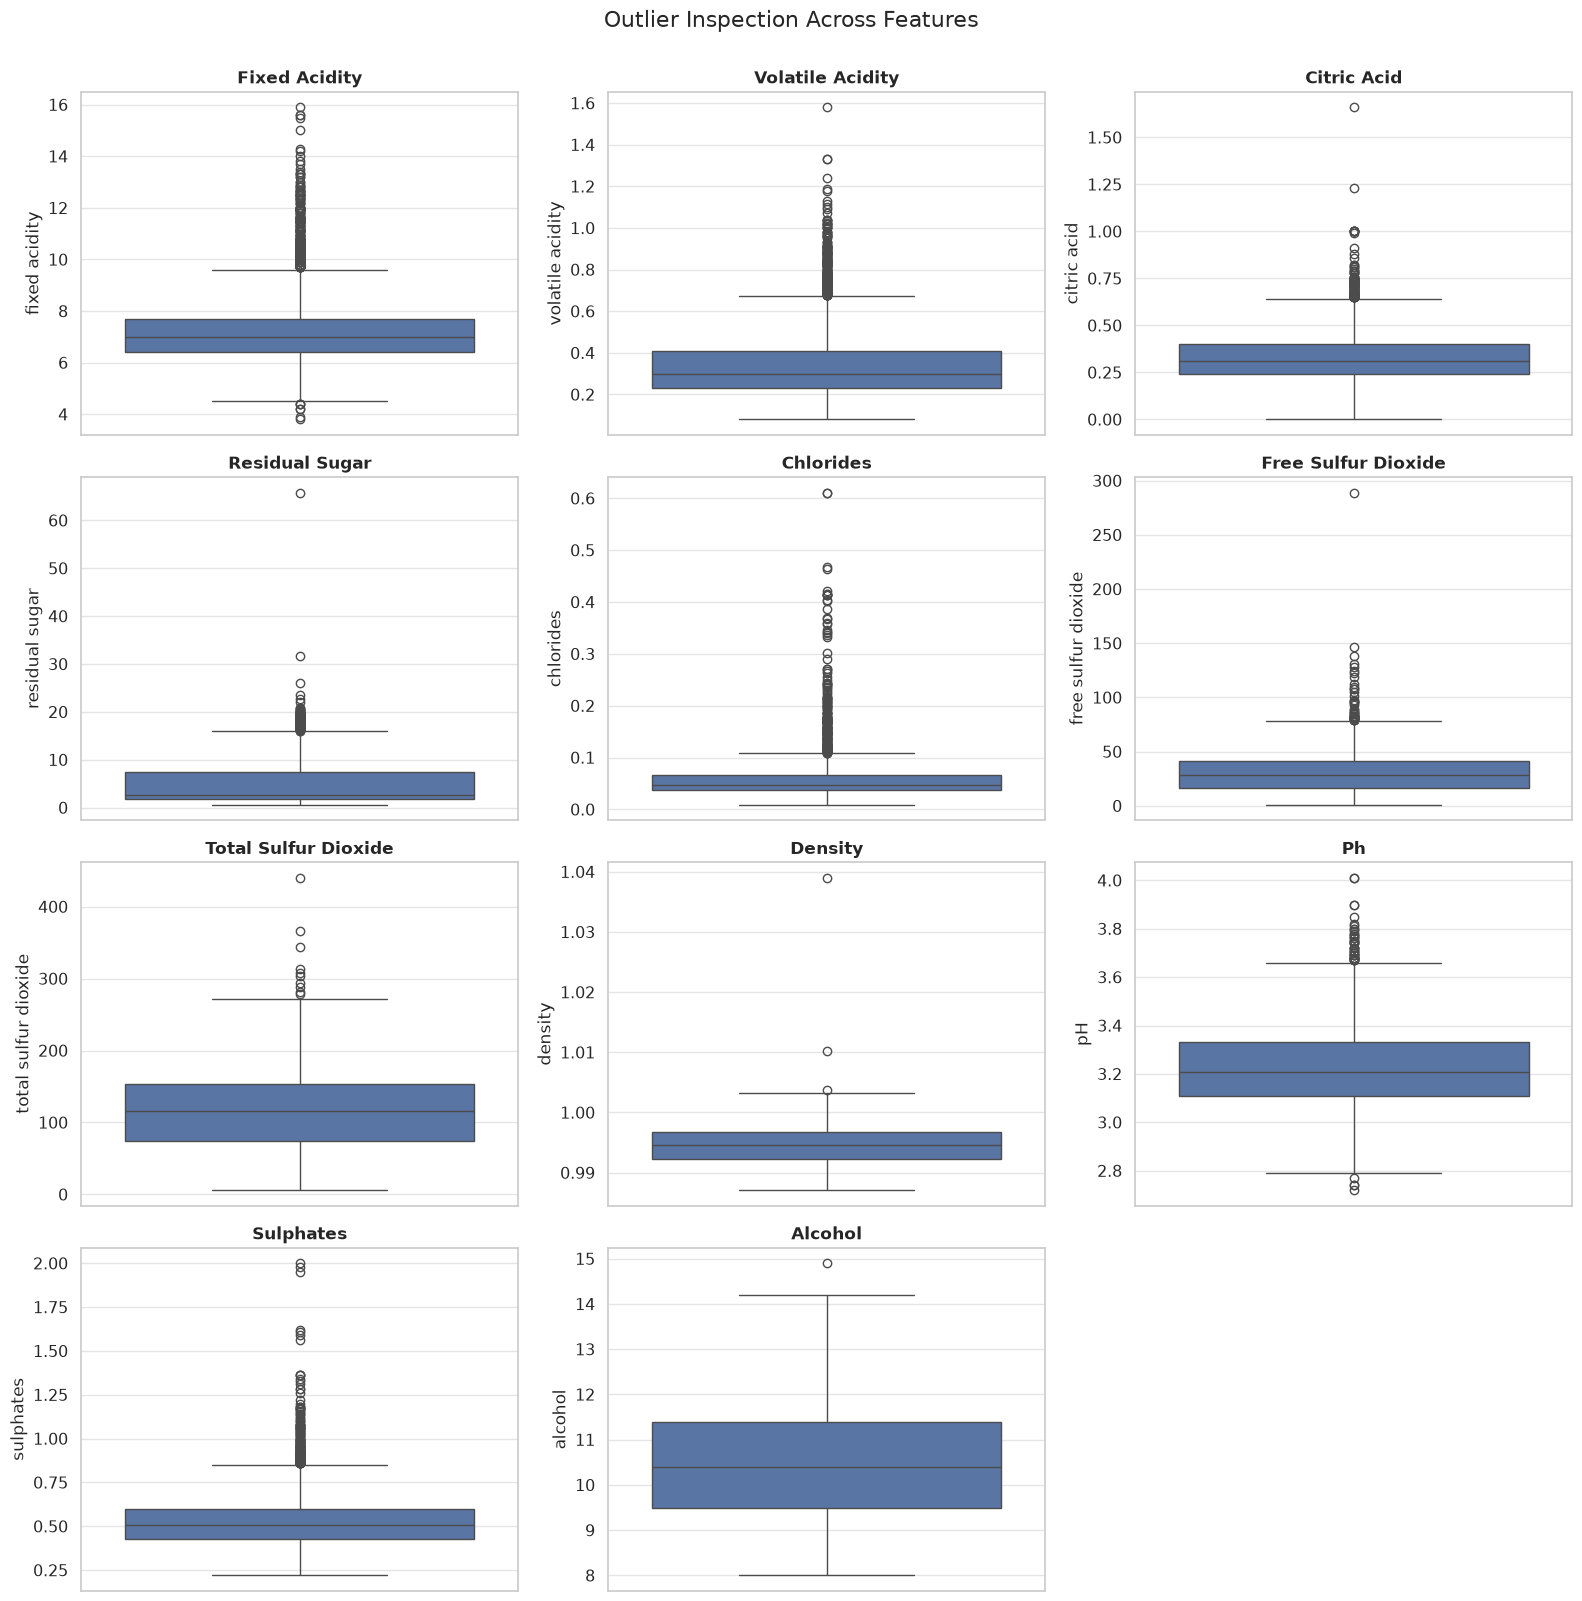

In [26]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='#4c72b0')
    axes[i].set_title(col.title())
axes[-1].axis('off')
plt.suptitle('Outlier Inspection Across Features', fontsize=16, y=1.0)
plt.tight_layout()
plt.savefig('outputs/07_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
def iqr_outlier_share(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).mean()

outlier_shares = df[feature_cols].apply(iqr_outlier_share).sort_values(ascending=False)
print("Share of IQR-based outliers per feature:")
outlier_shares


Share of IQR-based outliers per feature:


fixed acidity           0.057143
volatile acidity        0.052444
chlorides               0.044549
sulphates               0.030639
citric acid             0.026880
residual sugar          0.026504
pH                      0.009211
free sulfur dioxide     0.008271
total sulfur dioxide    0.001880
density                 0.000564
alcohol                 0.000188
dtype: float64

                  count  percent
quality_category                
Medium             2323     43.7
Low                1988     37.4
High               1009     19.0


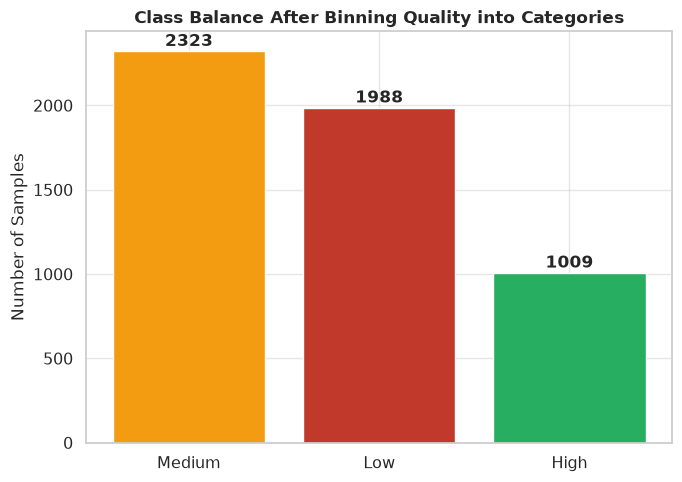

In [29]:
def quality_to_category(q):
    if q <= 5:
        return 'Low'
    elif q == 6:
        return 'Medium'
    else:
        return 'High'

df['quality_category'] = df['quality'].apply(quality_to_category)

cat_counts = df['quality_category'].value_counts()
cat_pct = df['quality_category'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': cat_counts, 'percent': cat_pct.round(1)})
print(summary)

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'Low': '#c0392b', 'Medium': '#f39c12', 'High': '#27ae60'}
ax.bar(summary.index, summary['count'], color=[colors[i] for i in summary.index])
ax.set_title('Class Balance After Binning Quality into Categories')
ax.set_ylabel('Number of Samples')
for i, v in enumerate(summary['count']):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/08_quality_category_balance.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
# Encode wine_type as a numeric feature (binary)
df['wine_type_encoded'] = df['wine_type'].map({'red': 0, 'white': 1})

FEATURE_COLS = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides',
                'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates',
                'alcohol', 'wine_type_encoded']

X = df[FEATURE_COLS].copy()
X.rename(columns={'wine_type_encoded': 'wine_type'}, inplace=True)
y_raw = df['quality_category']

le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Encoded classes:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Feature matrix shape:", X.shape)
X.head()


Encoded classes: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Feature matrix shape: (5320, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Training samples: {X_train.shape[0]}  |  Test samples: {X_test.shape[0]}")
print("\nClass balance (train):", np.bincount(y_train) / len(y_train))
print("Class balance (test): ", np.bincount(y_test) / len(y_test))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training samples: 4256  |  Test samples: 1064

Class balance (train): [0.18961466 0.37382519 0.43656015]
Class balance (test):  [0.18984962 0.3731203  0.43703008]


In [32]:
baseline_results = {}

# --- Logistic Regression ---
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
pred = log_reg.predict(X_test_scaled)
baseline_results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, pred),
    'macro_f1': f1_score(y_test, pred, average='macro'),
    'model': log_reg,
}

# --- Decision Tree ---
dtree = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dtree.fit(X_train, y_train)
pred = dtree.predict(X_test)
baseline_results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, pred),
    'macro_f1': f1_score(y_test, pred, average='macro'),
    'model': dtree,
}

# --- K-Nearest Neighbours ---
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
baseline_results['K-Nearest Neighbours'] = {
    'accuracy': accuracy_score(y_test, pred),
    'macro_f1': f1_score(y_test, pred, average='macro'),
    'model': knn,
}

for name, res in baseline_results.items():
    print(f"{name:22s}  Accuracy = {res['accuracy']:.4f}   Macro-F1 = {res['macro_f1']:.4f}")


Logistic Regression     Accuracy = 0.6071   Macro-F1 = 0.5702
Decision Tree           Accuracy = 0.5902   Macro-F1 = 0.5657
K-Nearest Neighbours    Accuracy = 0.5968   Macro-F1 = 0.5766


In [33]:
advanced_results = {}

rf = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
advanced_results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, pred), 'macro_f1': f1_score(y_test, pred, average='macro'), 'model': rf}

gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
advanced_results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_test, pred), 'macro_f1': f1_score(y_test, pred, average='macro'), 'model': gb}

xgb_clf = xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, random_state=RANDOM_STATE, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train)
pred = xgb_clf.predict(X_test)
advanced_results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, pred), 'macro_f1': f1_score(y_test, pred, average='macro'), 'model': xgb_clf}

for name, res in advanced_results.items():
    print(f"{name:22s}  Accuracy = {res['accuracy']:.4f}   Macro-F1 = {res['macro_f1']:.4f}")


Random Forest           Accuracy = 0.6419   Macro-F1 = 0.6204
Gradient Boosting       Accuracy = 0.6194   Macro-F1 = 0.5944
XGBoost                 Accuracy = 0.6410   Macro-F1 = 0.6280


In [49]:
param_dist = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [None, 10, 15, 20, 30],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2'],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist, n_iter=20, cv=3, scoring='accuracy',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0)

random_search.fit(X_train, y_train)

print("Best hyperparameters found:", random_search.best_params_)
print(f"Best CV accuracy: {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_
pred = best_rf.predict(X_test)
print(f"\nTuned Random Forest — Test Accuracy: {accuracy_score(y_test, pred):.4f}   "
      f"Macro-F1: {f1_score(y_test, pred, average='macro'):.4f}")


Best hyperparameters found: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 30}
Best CV accuracy: 0.6060

Tuned Random Forest — Test Accuracy: 0.6513   Macro-F1: 0.6239


In [35]:
voting_ensemble = VotingClassifier(
    estimators=[('random_forest', best_rf), ('gradient_boosting', gb), ('xgboost', xgb_clf)],
    voting='soft', weights=[2, 1, 2])

voting_ensemble.fit(X_train, y_train)
ensemble_pred = voting_ensemble.predict(X_test)
ensemble_proba = voting_ensemble.predict_proba(X_test)

print(f"Soft-Voting Ensemble — Test Accuracy: {accuracy_score(y_test, ensemble_pred):.4f}   "
      f"Macro-F1: {f1_score(y_test, ensemble_pred, average='macro'):.4f}")


Soft-Voting Ensemble — Test Accuracy: 0.6419   Macro-F1: 0.6213


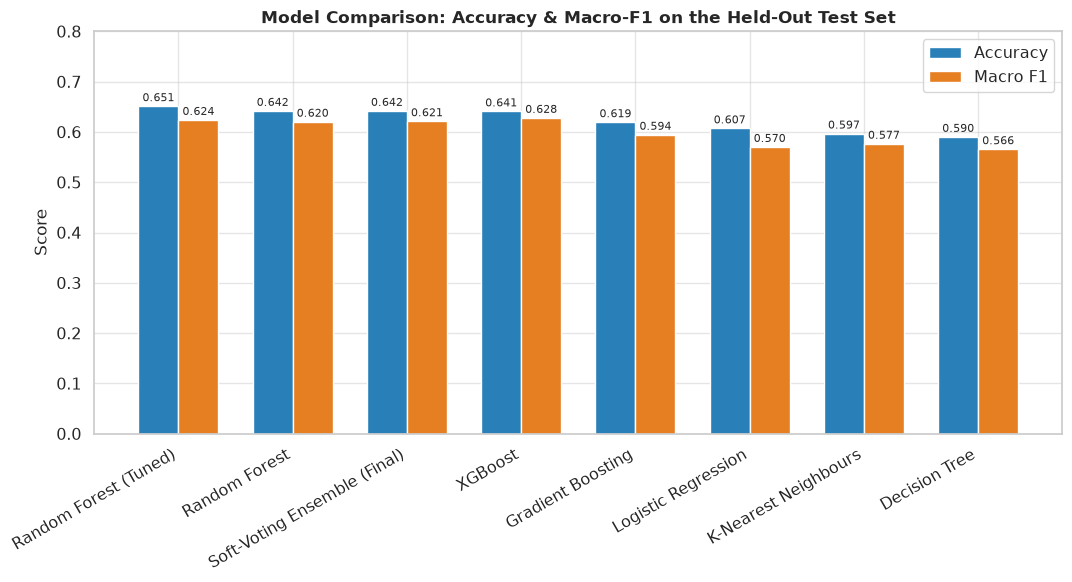

In [38]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison_df))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='#2980b9')
bars2 = ax.bar(x + width/2, comparison_df['Macro F1'], width, label='Macro F1', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=30, ha='right')
ax.set_ylim(0, 0.8)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy & Macro-F1 on the Held-Out Test Set')
ax.legend()
for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}',
                ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [39]:
print(classification_report(y_test, ensemble_pred, target_names=le.classes_))


              precision    recall  f1-score   support

        High       0.63      0.46      0.53       202
         Low       0.71      0.70      0.70       397
      Medium       0.60      0.67      0.63       465

    accuracy                           0.64      1064
   macro avg       0.64      0.61      0.62      1064
weighted avg       0.64      0.64      0.64      1064



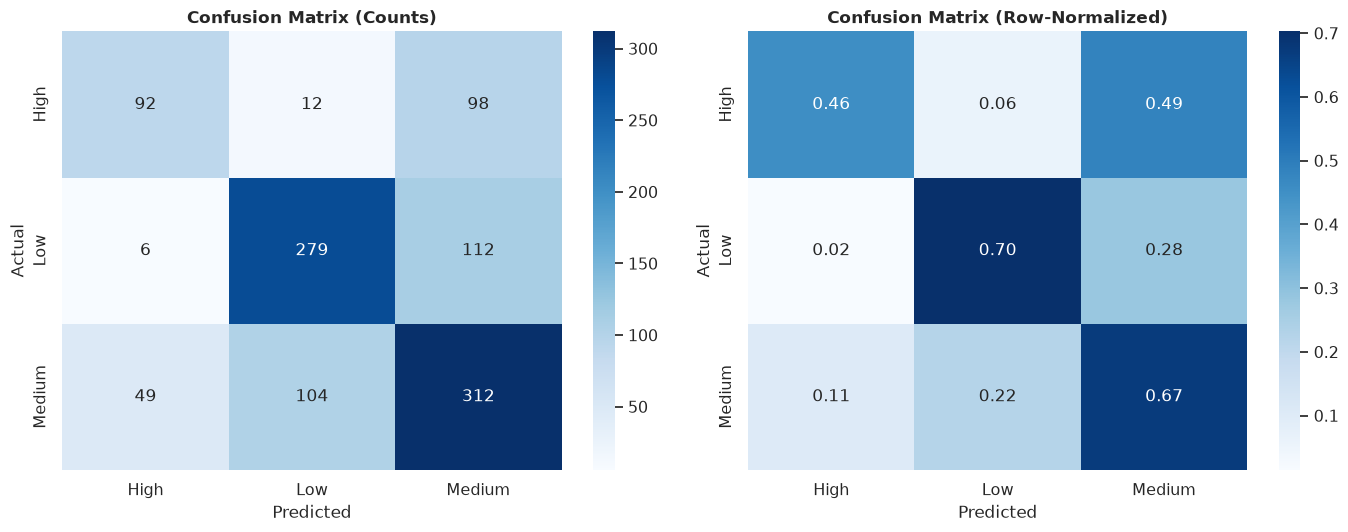

In [40]:
cm = confusion_matrix(y_test, ensemble_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (Row-Normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


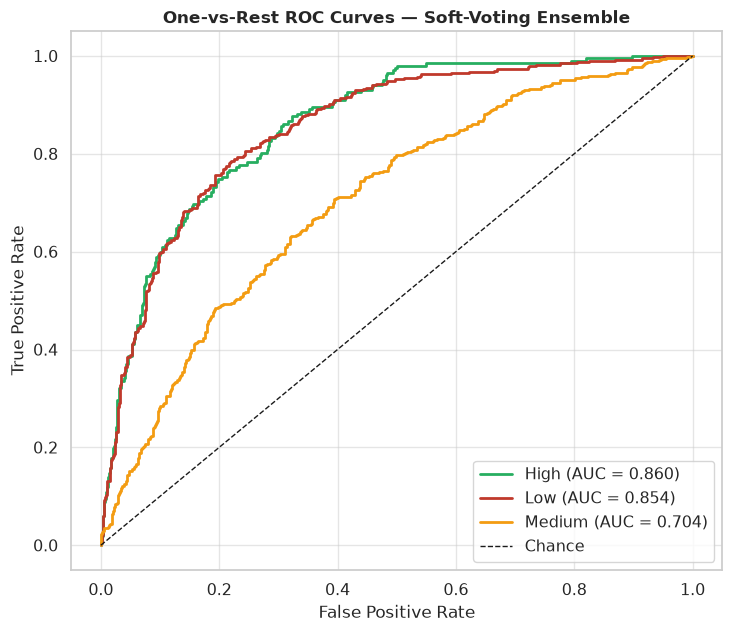


Macro-averaged ROC-AUC (One-vs-Rest): 0.8062


In [41]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
colors = ['#27ae60', '#c0392b', '#f39c12']
macro_auc_scores = []
for i, cls_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], ensemble_proba[:, i])
    roc_auc = auc(fpr, tpr)
    macro_auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{cls_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('One-vs-Rest ROC Curves — Soft-Voting Ensemble')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

macro_roc_auc = roc_auc_score(y_test, ensemble_proba, multi_class='ovr', average='macro')
print(f"\nMacro-averaged ROC-AUC (One-vs-Rest): {macro_roc_auc:.4f}")


5-Fold Stratified Cross-Validation Accuracy:
  Fold 1: 0.6231
  Fold 2: 0.6203
  Fold 3: 0.6212
  Fold 4: 0.6241
  Fold 5: 0.6344

Mean: 0.6246   Std: 0.0051


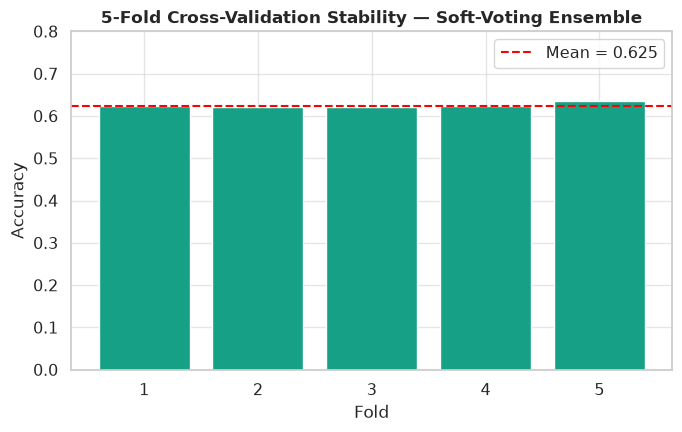

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(voting_ensemble, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("5-Fold Stratified Cross-Validation Accuracy:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nMean: {cv_scores.mean():.4f}   Std: {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(1, 6), cv_scores, color='#16a085')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Stability — Soft-Voting Ensemble')
ax.set_ylim(0, 0.8)
ax.legend()
plt.tight_layout()
plt.savefig('outputs/12_cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()


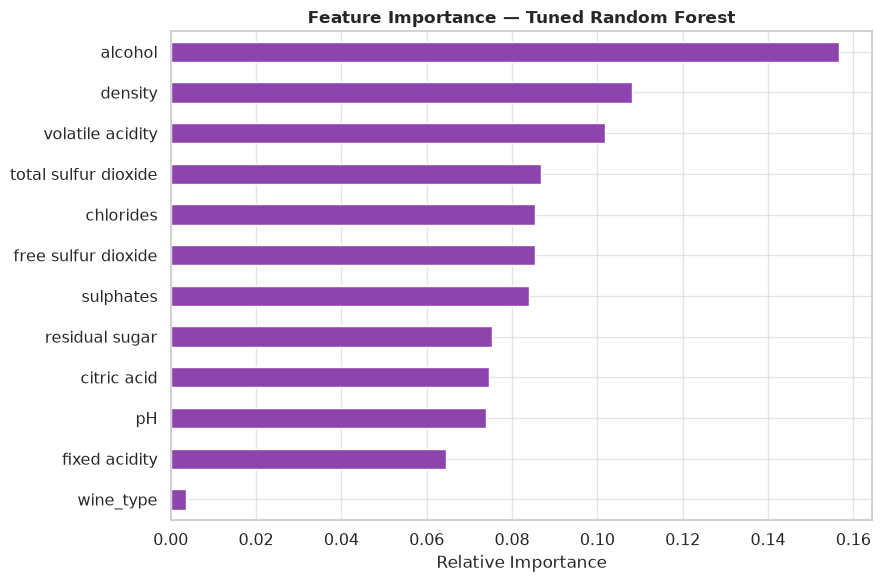

alcohol                 0.156594
density                 0.108194
volatile acidity        0.101746
total sulfur dioxide    0.086716
chlorides               0.085387
free sulfur dioxide     0.085287
sulphates               0.083978
residual sugar          0.075273
citric acid             0.074700
pH                      0.074005
fixed acidity           0.064573
wine_type               0.003549
dtype: float64

In [45]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', color='#8e44ad', ax=ax)
ax.invert_yaxis()
ax.set_title('Feature Importance — Tuned Random Forest')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('outputs/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importances


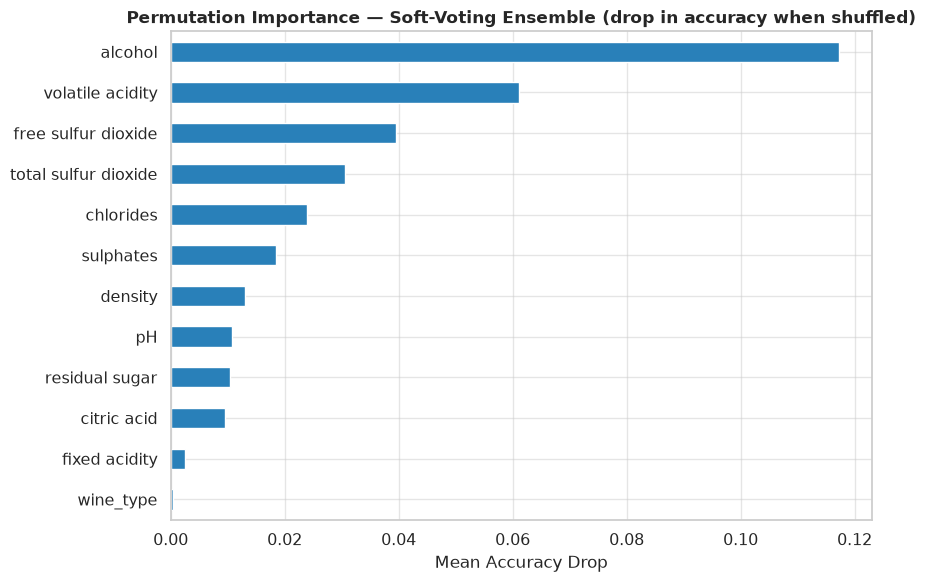

In [46]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(voting_ensemble, X_test, y_test, n_repeats=10,
                               random_state=RANDOM_STATE, scoring='accuracy', n_jobs=-1)
perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
perm_importances.plot(kind='barh', color='#2980b9', ax=ax)
ax.invert_yaxis()
ax.set_title('Permutation Importance — Soft-Voting Ensemble (drop in accuracy when shuffled)')
ax.set_xlabel('Mean Accuracy Drop')
plt.tight_layout()
plt.savefig('outputs/14_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [48]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(voting_ensemble, 'models/wine_quality_ensemble.joblib')
joblib.dump(best_rf, 'models/wine_quality_rf.joblib')
joblib.dump(le, 'models/label_encoder.joblib')
joblib.dump(list(X.columns), 'models/feature_cols.joblib')

metrics = {
    'accuracy': float(accuracy_score(y_test, ensemble_pred)),
    'macro_f1': float(f1_score(y_test, ensemble_pred, average='macro')),
    'macro_precision': float(precision_score(y_test, ensemble_pred, average='macro')),
    'macro_recall': float(recall_score(y_test, ensemble_pred, average='macro')),
    'macro_roc_auc': float(macro_roc_auc),
    'cv_mean_accuracy': float(cv_scores.mean()),
    'cv_std_accuracy': float(cv_scores.std()),
    'confusion_matrix': cm.tolist(),
    'classes': le.classes_.tolist(),
    'feature_importance': importances.to_dict(),
}
with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

feature_stats = df[[c for c in feature_cols]].describe().to_dict()
with open('models/feature_stats.json', 'w') as f:
    json.dump(feature_stats, f, indent=2)

print("Saved to disk:")
for fname in ['wine_quality_ensemble.joblib', 'wine_quality_rf.joblib', 'label_encoder.joblib',
              'feature_cols.joblib', 'metrics.json', 'feature_stats.json']:
    print(' -', os.path.join('models', fname))


Saved to disk:
 - models/wine_quality_ensemble.joblib
 - models/wine_quality_rf.joblib
 - models/label_encoder.joblib
 - models/feature_cols.joblib
 - models/metrics.json
 - models/feature_stats.json
